# EDA for policies exploration and core parameters identification

### 1. Import main libraries

This code will now include the necessary imports for numpy and pandas, alongside matplotlib.pyplot. It then reads the CSV file named 'cmf_policies.csv' into a pandas DataFrame named df. You can continue with your analysis or visualization code using this DataFrame.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv('cmf_policies.csv')

### 1.1 Investigating quantities and info

In [2]:
# Display first few rows
df.head()

,Código,Fecha Depósito,Nombre entidad que deposita,Texto depositado,Pólizas/Cláusulas,Temas,Res. Autoriza,Res. Prohibición
0,POL120240099,22/05/2024,CORREDORA DE SEGUROS BRISTOL SPA,póliza de garantía de corredor de seguros,NaN,- Varios Seg. Generales\n,-,-
1,POL120240098,20/05/2024,ASEGURADORA PORVENIR S.A.,PÓLIZA DE SEGURO DE CAUCIÓN PARA VEEDORES Y LI...,NaN,- Garantías y Fidelidad\n,-,-
2,POL320240097,16/05/2024,COLMENA COMPAÑIA DE SEGUROS DE VIDA S.A.,SEGURO COLECTIVO DE REEMBOLSO DE GASTOS MEDICO...,NaN,- Salud\n,-,-
3,CAD320240096,14/05/2024,BNP PARIBAS CARDIF SEGUROS GENERALES S.A.,CLAUSULA ADICIONAL DE INVALIDEZ ACCIDENTAL,POL120130166\n,- Accidentes Personales\n,-,-
4,CAD320240095,14/05/2024,BNP PARIBAS CARDIF SEGUROS GENERALES S.A.,CLAUSULA ADICIONAL DE INVALIDEZ PERMANENTE DOS...,POL120130166\n,- Accidentes Personales\n,-,-


In [3]:
# Indentify Info of the columns
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6715 entries, 0 to 6714
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Código                       6715 non-null   object
 1   Fecha Depósito               6715 non-null   object
 2   Nombre entidad que deposita  6715 non-null   object
 3   Texto depositado             6715 non-null   object
 4   Pólizas/Cláusulas            3243 non-null   object
 5   Temas                        6715 non-null   object
 6   Res. Autoriza                6715 non-null   object
 7   Res. Prohibición             6715 non-null   object
dtypes: object(8)
memory usage: 419.8+ KB
None


In [4]:
# Identify null values
df.isnull().sum()

Código                            0
Fecha Depósito                    0
Nombre entidad que deposita       0
Texto depositado                  0
Pólizas/Cláusulas              3472
Temas                             0
Res. Autoriza                     0
Res. Prohibición                  0
dtype: int64

### 2. Cleaning the dataset

This sample data represents a tabular dataset with information about deposited policies. Each row corresponds to a specific policy and contains details such as the policy code, deposit date, depositing entity, deposited text, and other related information.

The Python code following the data aims to analyze the dataset. It first extracts the year from the deposit date, then plots the number of policies deposited per year using a bar chart. The chart has a transparent background with white text, and the bars are colored in a specific color (#73e8cf). Finally, the plot is saved as an image named 'temp.png'.

Overall, the code visualizes the distribution of deposited policies over the years, providing insights into the trend of policy deposits.

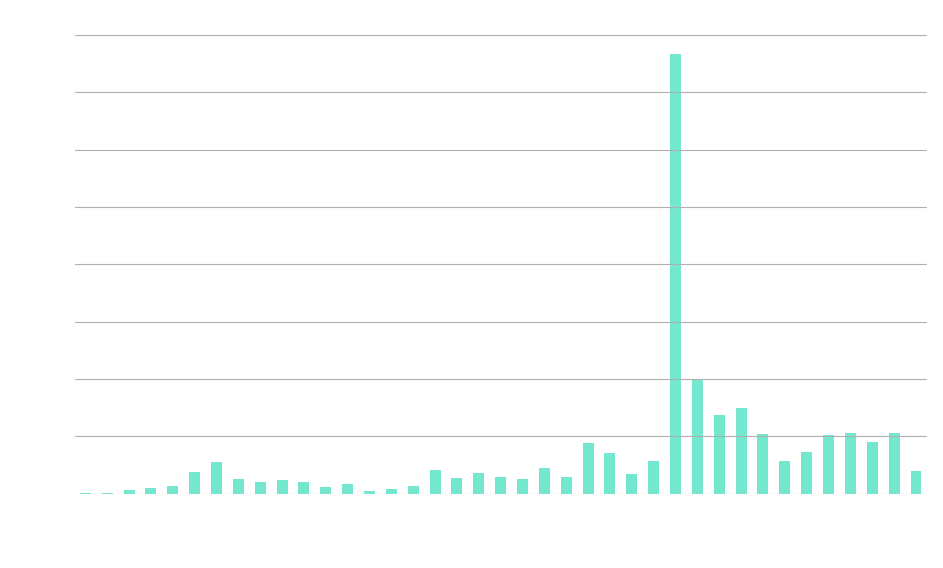

In [11]:

"""SAMPLE DATA
	Código	Fecha Depósito	Nombre entidad que deposita	Texto depositado	Pólizas/Cláusulas	Temas	Res. Autoriza	Res. Prohibición
0	POL120240099	22/05/2024	CORREDORA DE SEGUROS BRISTOL SPA	póliza de garantía de corredor de seguros	NaN	- Varios Seg. Generales\n	-	-
1	POL120240098	20/05/2024	ASEGURADORA PORVENIR S.A.	PÓLIZA DE SEGURO DE CAUCIÓN PARA VEEDORES Y LI...	NaN	- Garantías y Fidelidad\n	-	-
2	POL320240097	16/05/2024	COLMENA COMPAÑIA DE SEGUROS DE VIDA S.A.	SEGURO COLECTIVO DE REEMBOLSO DE GASTOS MEDICO...	NaN	- Salud\n	-	-
3	CAD320240096	14/05/2024	BNP PARIBAS CARDIF SEGUROS GENERALES S.A.	CLAUSULA ADICIONAL DE INVALIDEZ ACCIDENTAL	POL120130166\n	- Accidentes Personales\n	-	-
4	CAD320240095	14/05/2024	BNP PARIBAS CARDIF SEGUROS GENERALES S.A.	CLAUSULA ADICIONAL DE INVALIDEZ PERMANENTE DOS...	POL120130166\n	- Accidentes Personales\n	-	
"""
import datetime 
# Count the number of policies per year and plot, transparent background with white text and this color for the bars: #73e8cf
# dates are in format dd/mm/yyyy
#Year can
for row in df.iterrows():
    """fecha_deposito = str(row['Fecha Depósito']).strip()
    if fecha_deposito.startswith('Res.'):
        fecha_deposito = fecha_deposito.split('del')[1].strip()
    # Fecha deposito is in format dd/mm/yyyy
    df["deposit_date"] = datetime.date(
        year=int(fecha_deposito.split('/')[2]),
        month=int(fecha_deposito.split('/')[1]),
        day=int(fecha_deposito.split('/')[0])
    )
    df["deposit_year"] = df["deposit_date"].year"""

    df['deposit_year'] = df["Fecha Depósito"].apply(lambda x: x.split('/')[2])

fig = plt.figure(facecolor='none', figsize=(11, 6))

#WHITE TEXT
plt.rcParams.update({
    "text.color": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "axes.edgecolor": "white"
})

#COLOR FOR BARS
color = '#73e8cf'

#PLOT
df['deposit_year'].value_counts().sort_index().plot(kind='bar', color=color)
plt.title('Number of Policies Deposited per Year')
plt.grid(axis='y')
plt.xlabel('Year')
plt.ylabel('Number of Policies Deposited')
plt.xticks(rotation=45)
fig.savefig('temp.png', transparent=True, edgecolor='none')
plt.show()

This script creates a horizontal bar plot showing the count of policies for different topics. It uses a custom color palette and annotates each bar with its count.

The topics dictionary contains the topic names as keys and their corresponding counts as values. It's converted to uppercase to ensure consistency. Then, it's converted into a pandas DataFrame for easy manipulation and sorting based on the count.

<Figure size 1500x2000 with 0 Axes>

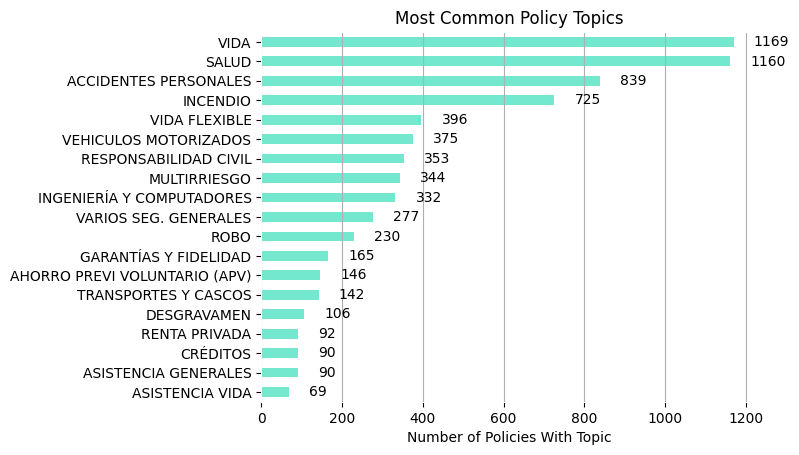

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Your data
topics = {
    'desgravamen': 106,
    'salud': 1160,
    'garantías y fidelidad': 165,
    'robo': 230,
    'vida': 1169,
    'incendio': 725,
    'varios seg. generales': 277,
    'responsabilidad civil': 353,
    'accidentes personales': 839,
    'asistencia vida': 69,
    'vida flexible': 396,
    'transportes y cascos': 142,
    'multirriesgo': 344,
    'créditos': 90,
    'asistencia generales': 90,
    'vehiculos motorizados': 375,
    'renta privada': 92,
    'ingeniería y computadores': 332,
    'ahorro previ voluntario (apv)': 146,
}

topics = {k.upper(): v for k, v in topics.items()}

df = pd.DataFrame.from_dict(topics, orient='index', columns=['count'])
df = df.sort_values(by = 'count', ascending=True)  # Sorting from least common to most common

# Define a custom color palette
custom_colors = ['#d62728','#2ca02c', '#bcbd22', '#ff7f0e', '#9467bd',
                 '#ffbb78', '#1f77b4', '#e377c2', '#7f7f7f', '#17becf',
                 '#aec7e8', '#ffbb78', '#98df8a', '#ff9896', '#c5b0d5', '#8c564b', '#c49c94', '#f7b6d2']

# WHITE TEXT
plt.rcParams.update({
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "white"
})

color = '#73e8cf'

fig = plt.figure(figsize=(15, 20))
ax = df.plot.barh(y='count', color=color, legend=False)
plt.title('Most Common Policy Topics')
plt.grid(axis='x')

# Annotate each bar with the count
for i in ax.patches:
    ax.text(
        i.get_width() + 50,  # x position, slightly to the right of the bar
        i.get_y() + i.get_height() / 2,  # y position, centered in the bar
        f'{int(i.get_width())}',  # Text: the width of the bar (the count)
        ha='left',  # Horizontal alignment: left
        va='center'  # Vertical alignment: center
    )

plt.ylabel('')  # Remove y-label
plt.xlabel('Number of Policies With Topic')
plt.savefig('temp.png', transparent=True, bbox_inches='tight')  # Save figure
plt.show()



This script generates a horizontal bar plot to visualize the count of different policy types. It annotates each bar with its count and saves the plot as 'temp.png'.

<Figure size 1100x600 with 0 Axes>

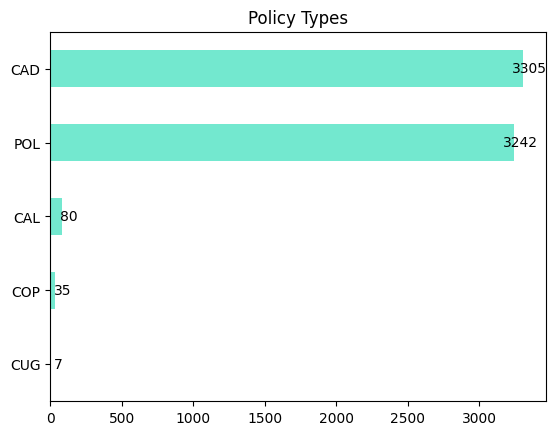

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Policy types data
policy_types = {'POL': 3242, 'CAD': 3305, 'CUG': 7, 'CAL': 80, 'COP': 35}

# Convert dictionary to DataFrame
df = pd.DataFrame.from_dict(policy_types, orient='index', columns=['count'])
df = df.sort_values(by='count', ascending=True)  # Sorting from least common to most common

# WHITE TEXT
plt.rcParams.update({
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.edgecolor": "black"
})

# Plot horizontal bar plot
fig = plt.figure(facecolor='none', figsize=(11, 6))
ax = df.plot.barh(color='#73e8cf', legend=False)

# Title
plt.title('Policy Types')

# Annotate each bar with the count
for i in ax.patches:
    ax.text(
        i.get_width() + 50,  # x position, slightly to the right of the bar
        i.get_y() + i.get_height() / 2,  # y position, centered in the bar
        f'{int(i.get_width())}',  # Text: the width of the bar (the count)
        ha='center',  # Horizontal alignment: center
        va='center'  # Vertical alignment: center
    )

# Get percentages
percentages = ['{:.1f}%'.format(100.*val/df['count'].sum()) for val in df['count']]
labels = ['{} - {}'.format(ind, perc) for ind, perc in zip(df.index, percentages)]

plt.savefig('temp.png', edgecolor='none')  # Save figure
plt.show()